<a href="https://colab.research.google.com/github/JoBahh/Multimodal-Sentiment-Analysis/blob/main/Multimodal-Sentiment-Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Amazon Review Sentiment Analysis

## Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import os
import time
from io import BytesIO
import ast

from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from wordcloud import WordCloud, STOPWORDS # For wordcloud visual

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import WeightedRandomSampler
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision import transforms

In [ ]:
#import gzip
#import json
#import pandas as pd
#from langdetect import detect, LangDetectException

#input_file = "Toys_and_Games.jsonl.gz"

#rows = []

#with gzip.open(input_file, "rt", encoding="utf-8") as f:
#    for i, line in enumerate(f, start=1):
#        data = json.loads(line)
#
#        text = data.get("text")
#        rating = data.get("rating")
#        images = data.get("images")

#        cleaned_text = str(text).strip() if text is not None else ""

#        if (
#            cleaned_text != ""
#            and len(cleaned_text) > 20
#            and rating is not None
#            and images is not None
#            and len(images) > 0
#        ):
#            rows.append({
#                "text": cleaned_text,
#                "rating": rating,
#                "images": images
#            })

#df = pd.DataFrame(rows)

# random sample first
#sample_n = min(30000, len(df))
#df = df.sample(n=sample_n, random_state=42).reset_index(drop=True)

#def is_english(text):
#    try:
#        return detect(text) == "en"
#    except LangDetectException:
#        return False

#df = df[df["text"].apply(is_english)].reset_index(drop=True)

#df.to_csv("toys_games_30k_final.csv", index=False)

#print("Saved cleaned dataset to toys_games_30k_final.csv")
#print(df.head())

Reviews were filtered to include only entries containing text, ratings, and associated images. Reviews with fewer than 20 characters were removed to eliminate low information entries. Language detection was used to retain only English reviews. From the resulting dataset, a random sample of approximately 30,000 reviews was selected for analysis.

## Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/STAT_315_Project/toys_games_30k_final.csv")

,text,rating,images
0,Really excited to have this in my collection,5.0,[{'small_image_url': 'https://m.media-amazon.c...
1,Great size and quality for the money,5.0,[{'small_image_url': 'https://m.media-amazon.c...
2,"I was able to find this doll at Target, and wa...",4.0,[{'small_image_url': 'https://images-na.ssl-im...
3,Super cute. Bigger than I expected but I may h...,5.0,[{'small_image_url': 'https://m.media-amazon.c...
4,My package was missing a hello kitty bag it wa...,4.0,[{'small_image_url': 'https://m.media-amazon.c...


In [ ]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nInfo:")
print(df.info())

df.head()

Shape: (29313, 3)

Columns: Index(['text', 'rating', 'images'], dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29313 entries, 0 to 29312
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   text    29313 non-null  object 
 1   rating  29313 non-null  float64
 2   images  29313 non-null  object 
dtypes: float64(1), object(2)
memory usage: 687.2+ KB
None


,text,rating,images
0,Really excited to have this in my collection,5.0,[{'small_image_url': 'https://m.media-amazon.c...
1,Great size and quality for the money,5.0,[{'small_image_url': 'https://m.media-amazon.c...
2,"I was able to find this doll at Target, and wa...",4.0,[{'small_image_url': 'https://images-na.ssl-im...
3,Super cute. Bigger than I expected but I may h...,5.0,[{'small_image_url': 'https://m.media-amazon.c...
4,My package was missing a hello kitty bag it wa...,4.0,[{'small_image_url': 'https://m.media-amazon.c...


## Data Cleaning

### Image Preprocessing

In [ ]:
# Create copy of existing dataset
df_clean = df.copy()

# Converting images to string
df_clean["images"] = df_clean["images"].astype(str)

### Text Length

In [ ]:
df_clean["text_length"] = df_clean["text"].str.len()
df_clean["text_length"]

,text_length
0,44
1,36
2,709
3,127
4,84
...,...
29308,119
29309,182
29310,557
29311,81


### Image URL Extraction

In [ ]:
# Helper function to extract URL of largest image for each review
def get_url(x):
    try:
        data = ast.literal_eval(x) if isinstance(x, str) else x
        return data[0]["large_image_url"] if data else None
    except:
        return None

df_clean["image_url"] = df_clean["images"].apply(get_url)
df_clean["image_url"]

,image_url
0,https://m.media-amazon.com/images/I/81i9Iz21f4...
1,https://m.media-amazon.com/images/I/61Jn+XiB3X...
2,https://images-na.ssl-images-amazon.com/images...
3,https://m.media-amazon.com/images/I/81ddcPWC-R...
4,https://m.media-amazon.com/images/I/81jIrw2SGP...
...,...
29308,https://m.media-amazon.com/images/I/B1H1jZkoR0...
29309,https://images-na.ssl-images-amazon.com/images...
29310,https://images-na.ssl-images-amazon.com/images...
29311,https://images-na.ssl-images-amazon.com/images...


### Feature Engineering

In [ ]:
# Sentiment column
def rating_to_sentiment(r):
    if r <= 2:
        return "Negative"
    elif r <= 4:
        return "Neutral"
    else:
        return "Positive"

df_clean["sentiment"] = df_clean["rating"].apply(rating_to_sentiment)

print(df_clean["sentiment"].value_counts(normalize=True)*100)

sentiment
Positive    59.059121
Negative    22.092587
Neutral     18.848293
Name: proportion, dtype: float64


### Sentiment Map

In [ ]:
# Encoding sentiment labels
label_map = {"Negative": 0, "Neutral": 1, "Positive": 2}
df_clean["sentiment_map"] = df_clean["sentiment"].map(label_map)

### Save to New CSV

In [ ]:
# Reset index
df_clean = df_clean.reset_index(drop=True)

# Save to new CSV
df_clean.to_csv("cleaned_reviews.csv", index=False)

### Load Cleaned Data

In [ ]:
# Pranav code to read file
path = "/content/drive/MyDrive/STAT_315_Project/cleaned_reviews.csv"

df = pd.read_csv(path)

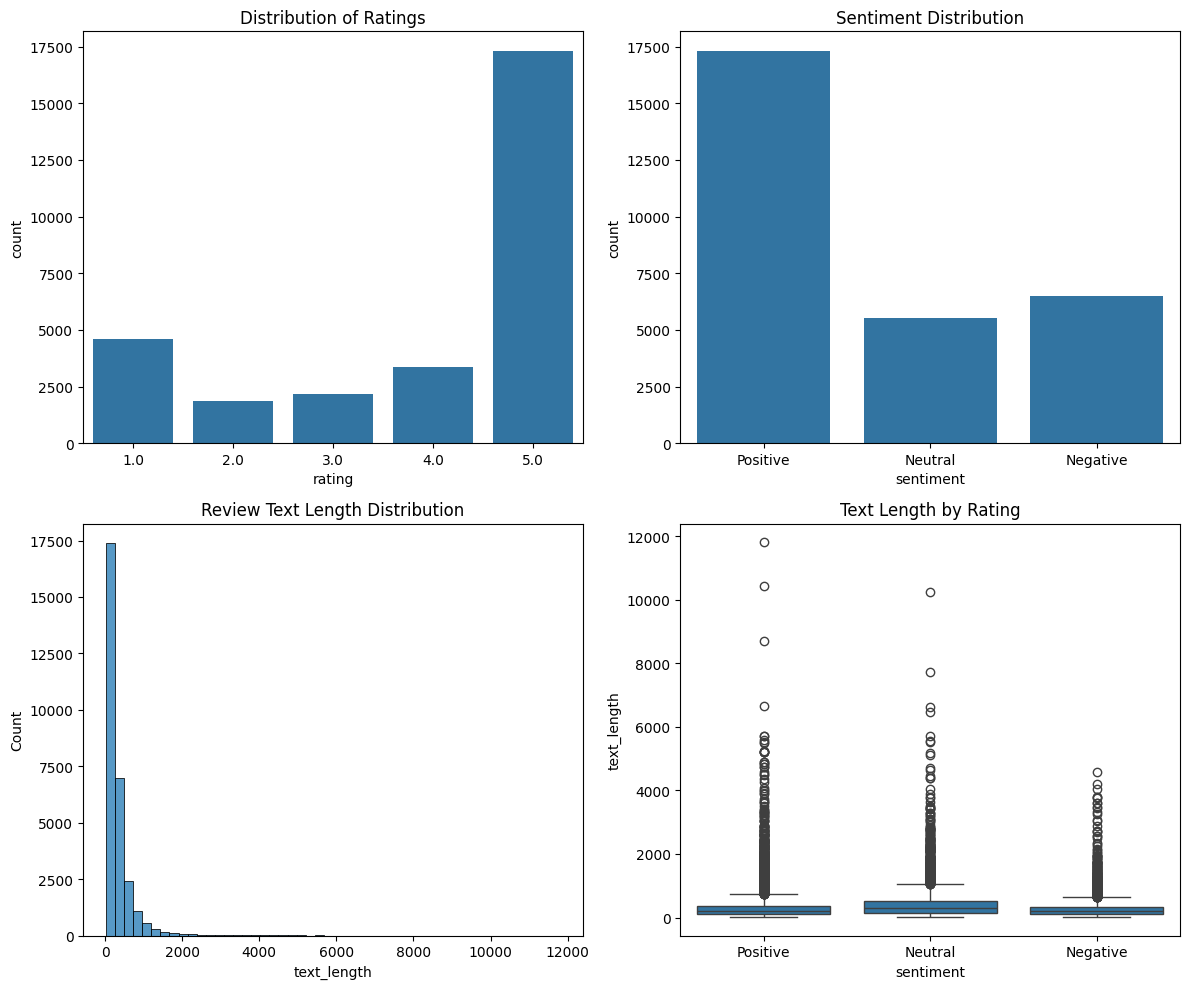

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Rating distribution
sns.countplot(x="rating", data=df, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Ratings")

# 2. Sentiment distribution
sns.countplot(x="sentiment", data=df, ax=axes[0, 1])
axes[0, 1].set_title("Sentiment Distribution")

# 3. Text length histogram
sns.histplot(df["text_length"], bins=50, ax=axes[1, 0])
axes[1, 0].set_title("Review Text Length Distribution")

# 4. Boxplot: text length by sentiment
sns.boxplot(x="sentiment", y="text_length", data=df, ax=axes[1, 1])
axes[1, 1].set_title("Text Length by Rating")

plt.tight_layout()
plt.show()

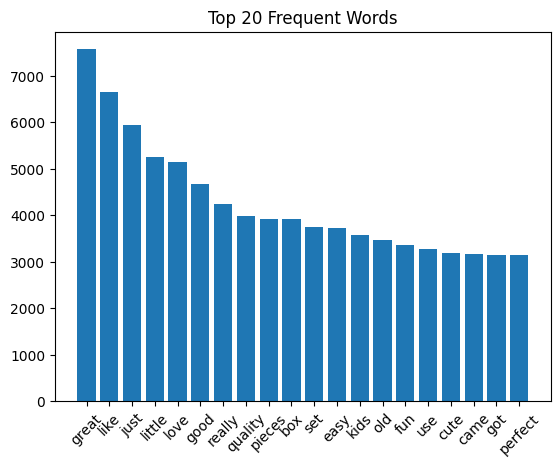

In [ ]:
def clean_text(t):
    t = t.lower()
    t = re.sub(r"[^a-z\s]", "", t)
    return t

stop = set(ENGLISH_STOP_WORDS)

words = " ".join(df["text"].apply(clean_text)).split()
words = [w for w in words if w not in stop and len(w) >= 3]
top20 = Counter(words).most_common(20)

w, c = zip(*top20)

plt.figure()
plt.bar(w, c)
plt.xticks(rotation=45)
plt.title("Top 20 Frequent Words")
plt.show()

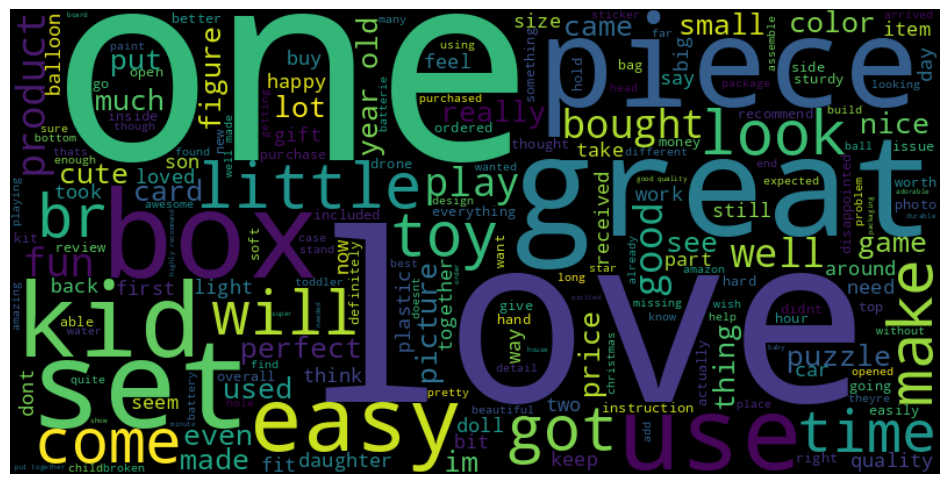

In [ ]:
# Creating wordcloud to see most popular words (accounting for stopwords)
words = " ".join(df["text"].dropna().astype(str))
words = words.lower()
words = re.sub(r"[^\w\s]", "", words)

# Set stopwords to default stopwords
stopwords = set(STOPWORDS)

# Generate word cloud
wordcloud = WordCloud(
    width = 800,
    height = 400,
    background_color = "black",
    stopwords = stopwords,
).generate(words)

# Create plot
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis('off')
plt.show()

# Text-Only Logistic Regression Model

Text-only Accuracy: 0.7637025244484876

Classification report:
               precision    recall  f1-score   support

    Negative       0.73      0.79      0.76      1943
     Neutral       0.46      0.52      0.49      1657
    Positive       0.89      0.83      0.86      5194

    accuracy                           0.76      8794
   macro avg       0.70      0.71      0.70      8794
weighted avg       0.78      0.76      0.77      8794



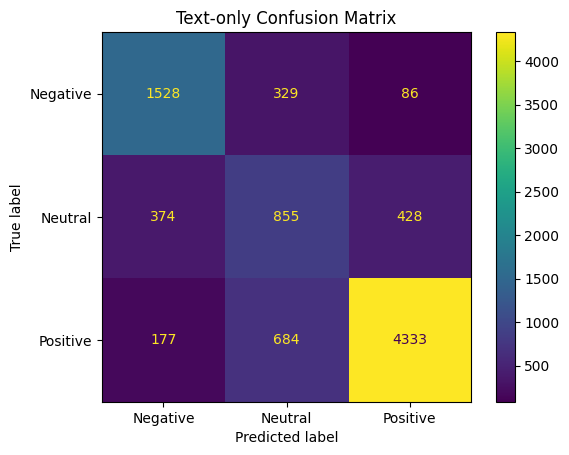

In [ ]:
# X = text, y = sentiment
X = df["text"].astype(str)
y = df["sentiment"].astype(str)

# Train/test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

text_clf = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        lowercase=True,
        max_features=50000,
        ngram_range=(1, 2)
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

text_clf.fit(X_train, y_train)

# Predictions
y_pred = text_clf.predict(X_test)

print("Text-only Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=text_clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=text_clf.classes_)
disp.plot(values_format="d")
plt.title("Text-only Confusion Matrix")
plt.show()

# PyTorch Multimodal CNN Model (Text + Images)

### Encoding Text

In [ ]:
def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

counter = Counter()
for t in df["text"]:
    counter.update(tokenize(t))

vocab = {w: i+2 for i, (w, _) in enumerate(counter.items())}
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1

MAX_LEN = 100

def encode(text):
    tokens = tokenize(text)
    ids = [vocab.get(t, 1) for t in tokens][:MAX_LEN]
    return ids + [0] * (MAX_LEN - len(ids))

## Image Transforms

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

### Dataset Class

In [ ]:
class ReviewDataset(Dataset):
    def __init__(self, df, text_encoder, image_transform=None):
        self.df = df.reset_index(drop=True)
        self.text_encoder = text_encoder
        self.image_transform = image_transform

    def load_image(self, url):
        try:
            response = requests.get(url, timeout=5)
            img = Image.open(BytesIO(response.content)).convert("RGB")
            if self.image_transform:
                img = self.image_transform(img)
            return img
        except:
            # fallback: black image if download fails
            return torch.zeros(3, 224, 224)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Text
        text = torch.tensor(
            self.text_encoder(row["text"]),
            dtype=torch.long
        )

        # Image
        image = self.load_image(row["image_url"])

        # Label
        label = torch.tensor(row["sentiment_map"], dtype=torch.long)

        return text, image, label

### Train/Test/Split

In [ ]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment"]
)

### Creating Datasets and DataLoaders

In [ ]:
train_dataset = ReviewDataset(train_df, text_encoder=encode, image_transform=transform)
val_dataset = ReviewDataset(val_df, text_encoder=encode, image_transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### Multimodal Class Definition

In [ ]:
class MultiModalModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=3):
        super().__init__()

        # Text
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

        # Image
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.cnn = nn.Sequential(*list(resnet.children())[:-1])
        self.img_fc = nn.Linear(512, hidden_dim)

        # Fusion
        self.gate = nn.Linear(hidden_dim * 2, hidden_dim)

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, text, image):

        # Text
        x_text = self.embedding(text)
        _, (h, _) = self.lstm(x_text)
        text_feat = h.squeeze(0)

        # Image
        x_img = self.cnn(image)
        x_img = x_img.view(x_img.size(0), -1)
        img_feat = self.img_fc(x_img)

        # Fusion
        combined = torch.cat([text_feat, img_feat], dim=1)

        gate = torch.sigmoid(self.gate(combined))

        fused = gate * text_feat + (1 - gate) * img_feat

        # Classifier
        out = self.classifier(fused)

        return out

### Setup

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MultiModalModel(vocab_size=len(vocab)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

### Training and Validation Loop

In [ ]:
best_acc = 0

for epoch in range(5):
    # Train
    model.train()
    train_loss = 0

    for text, image, label in train_loader:
        text = text.to(device)
        image = image.to(device)
        label = label.to(device)

        optimizer.zero_grad()

        outputs = model(text, image)
        loss = criterion(outputs, label)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    correct = 0

    with torch.no_grad():
        for text, image, label in val_loader:
            text = text.to(device)
            image = image.to(device)
            label = label.to(device)

            outputs = model(text, image)
            loss = criterion(outputs, label)

            val_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == label).sum().item()

    val_acc = correct / len(val_dataset)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Acc: {val_acc:.4f}")
    print("-" * 30)

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pt")

Epoch 1
Train Loss: 708.7713
Val Loss: 175.6331
Val Acc: 0.5907
------------------------------
Epoch 2
Train Loss: 705.7933
Val Loss: 176.2340
Val Acc: 0.5907
------------------------------
Epoch 3
Train Loss: 705.3133
Val Loss: 175.6551
Val Acc: 0.5907
------------------------------
Epoch 4
Train Loss: 624.6406
Val Loss: 123.8548
Val Acc: 0.7150
------------------------------
Epoch 5
Train Loss: 447.4365
Val Loss: 108.5587
Val Acc: 0.7552
------------------------------


### Evaluation

              precision    recall  f1-score   support

    Negative       0.68      0.80      0.74      1295
     Neutral       0.47      0.13      0.20      1105
    Positive       0.80      0.94      0.87      3463

    accuracy                           0.76      5863
   macro avg       0.65      0.62      0.60      5863
weighted avg       0.71      0.76      0.71      5863



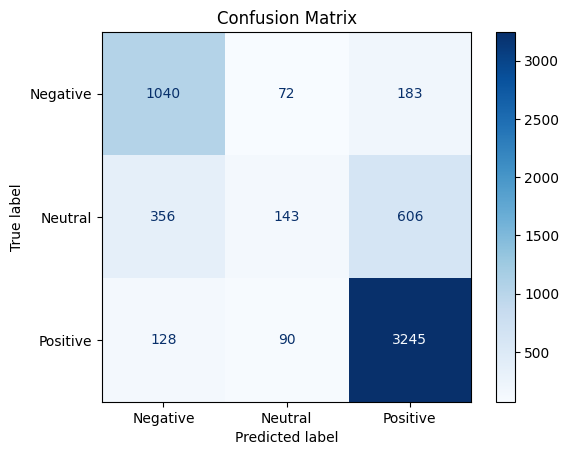

In [ ]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for text, image, label in val_loader:
        text = text.to(device)
        image = image.to(device)

        outputs = model(text, image)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(label.numpy())

# Classification Report
print(classification_report(
    all_labels,
    all_preds,
    target_names=["Negative", "Neutral", "Positive"]
))

# Confusion Matrix display
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Neutral", "Positive"]
)

disp.plot(values_format="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

As we can see, the multimodal model performed very well on the positive class but very poorly on the neutral class. This can be attributed to the imbalanced data so let's handle this.

## Fine-Tuning

### Class Weights

In [ ]:
class_counts = df["sentiment"].value_counts()

counts = np.array([
    class_counts["Negative"],
    class_counts["Neutral"],
    class_counts["Positive"]
], dtype=np.float32)

# inverse log scaling
weights = 1.0 / np.log1p(counts)

# normalize so weights sum to 1
weights = weights / weights.sum()

weights = torch.tensor(weights, dtype=torch.float).to(device)

print(weights)

tensor([0.3427, 0.3491, 0.3082], device='cuda:0')


### Plugging into Loss function

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

## Re-Run Train and Validation Loop

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.2, patience=1
)

best_val_loss = float("inf")

for epoch in range(5):

    # Training
    model.train()
    train_loss = 0

    for text, image, label in train_loader:
      text, image, label = text.to(device), image.to(device), label.to(device)

      optimizer.zero_grad(set_to_none=True)

      outputs = model(text, image)

      loss_per_sample = F.cross_entropy(outputs, label, reduction="none")

      weights = torch.ones_like(label, dtype=torch.float)
      weights[label == 1] = 2

      loss = (loss_per_sample * weights.to(loss_per_sample.device)).mean()

      loss.backward()

      torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

      optimizer.step()

      train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for text, image, label in val_loader:
            text, image, label = text.to(device), image.to(device), label.to(device)

            outputs = model(text, image)
            loss = criterion(outputs, label)

            val_loss += loss.item()

            preds = outputs.argmax(dim=1).detach().cpu()
            label = label.detach().cpu()

            correct += (preds == label).sum().item()
            total += label.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Acc: {val_acc:.4f}")
    print("---" * 10)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")

Epoch 1
Train Loss: 0.6836
Val Loss: 0.7202
Val Acc: 0.7247
------------------------------
Epoch 2
Train Loss: 0.6801
Val Loss: 0.7208
Val Acc: 0.7239
------------------------------
Epoch 3
Train Loss: 0.6720
Val Loss: 0.7311
Val Acc: 0.7261
------------------------------
Epoch 4
Train Loss: 0.6665
Val Loss: 0.7312
Val Acc: 0.7256
------------------------------
Epoch 5
Train Loss: 0.6670
Val Loss: 0.7310
Val Acc: 0.7252
------------------------------


### Re-Evaluate

Pred distribution: [1087 1445 3331]
              precision    recall  f1-score   support

    Negative       0.76      0.64      0.69      1295
     Neutral       0.36      0.47      0.41      1105
    Positive       0.87      0.84      0.86      3463

    accuracy                           0.73      5863
   macro avg       0.66      0.65      0.65      5863
weighted avg       0.75      0.73      0.74      5863



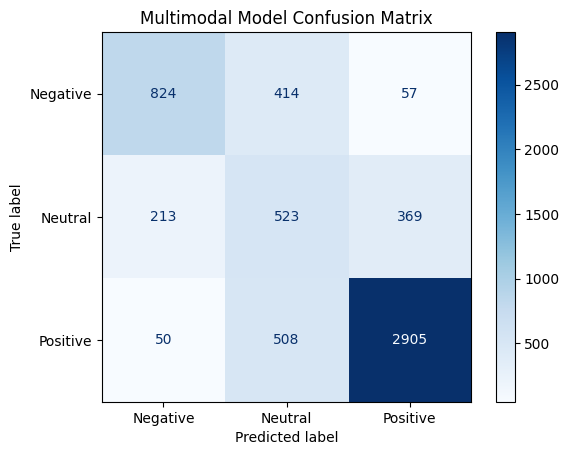

In [ ]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for text, image, label in val_loader:
        text = text.to(device)
        image = image.to(device)

        outputs = model(text, image)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(label.numpy())

print("Pred distribution:", np.bincount(all_preds))

# Classification Report
print(classification_report(
    all_labels,
    all_preds,
    target_names=["Negative", "Neutral", "Positive"]
))

# Confusion Matrix display
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Neutral", "Positive"]
)

disp.plot(values_format="d", cmap="Blues")
plt.title("Multimodal Model Confusion Matrix")
plt.show()